<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license. (c) Kyle T. Mandli</td>
</table>

In [3]:
from __future__ import print_function

%matplotlib inline

import numpy
import matplotlib.pyplot as plt

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

**MATERI 03 FINITE DIFFERENCES**

</div>

<div style="text-align: justify; font-family: 'Times New Roman',

**Review** : *Finite differences* adalah cara untuk memperkirakan turunan suatu fungsi dengan menggunakan beberapa nilai fungsi pada titik-titik tertentu, yang sering disebut sebagai stencil. Metode ini memiliki beberapa variasi, seperti jenis stencil yang digunakan, tingkat ketelitian *(order of accuracy)*, dan tingkat turunan yang dihitung *(order of derivatives)*. Dalam materi ini akan dibahas kembali bagaimana cara menurunkan rumusnya, menganalisis kesalahannya, dan bagaimana metode *finite differences* digunakan dalam perhitungan.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

**Review** : *Finite differences* adalah cara untuk memperkirakan turunan suatu fungsi dengan menggunakan beberapa nilai fungsi pada titik-titik tertentu, yang sering disebut sebagai stencil. Metode ini memiliki beberapa variasi, seperti jenis stencil yang digunakan, tingkat ketelitian *(order of accuracy)*, dan tingkat turunan yang dihitung *(order of derivatives)*. Dalam materi ini akan dibahas kembali bagaimana cara menurunkan rumusnya, menganalisis kesalahannya, dan bagaimana metode finite differences digunakan dalam perhitungan.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

**1. Forward Difference (Maju)**

Metode *forward difference* menggunakan nilai fungsi pada titik $x_i$ dan titik di depannya $x_i + \Delta x$.

$$
D_+ u(x_i) = \frac{u(x_i + \Delta x) - u(x_i)}{\Delta x}
$$

Artinya turunan diperkirakan dari perubahan nilai fungsi ke arah **depan**.



**2. Central Difference (Tengah)**

Metode *central difference* menggunakan nilai fungsi di depan dan di belakang titik $x_i$.

$$
D_0 u(x_i) = \frac{u(x_i + \Delta x) - u(x_i - \Delta x)}{2\Delta x}
$$

Metode ini biasanya **lebih akurat** karena menggunakan dua sisi titik.


**3. Backward Difference (Mundur)**

Metode *backward difference* menggunakan nilai fungsi pada titik $x_i$ dan titik sebelumnya $x_i - \Delta x$.

$$
D_u(x_i) = \frac{u(x_i) - u(x_i - \Delta x)}{\Delta x}
$$

Turunan diperkirakan dari perubahan nilai fungsi ke arah **belakang**.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Jika alih-alih membiarkan $\Delta x \rightarrow 0$ kita membuat suatu pendekatan terhadap kemiringan $u'(x_i)$, maka definisi turunan kita secara langsung dapat dipandang sebagai pendekatan terhadap turunan ketika $\Delta x$ mungkin kecil tetapi tidak sama dengan nol.

Untuk bagian tinjauan selanjutnya, kita akan mempelajari cara yang lebih sistematis untuk menurunkan pendekatan-pendekatan ini, serta menemukan pendekatan dengan orde ketelitian yang lebih tinggi, pendekatan untuk turunan orde yang lebih tinggi, dan memahami kesalahan *(error)* yang terkait dengan pendekatan tersebut.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### **Interpolating Polynomials (Polinomial Interpolasi)**

Salah satu cara mendapatkan rumus **finite difference** adalah dengan membuat polinomial interpolasi, lalu menurunkannya.

**Langkah-langkahnya adalah sebagai berikut:**

**a. Ide dasar**
Misalkan kita mengetahui nilai suatu fungsi di beberapa titik:

$$
(x_0,u(x_0)),\ (x_1,u(x_1)),\ \ldots,\ (x_N,u(x_N))
$$

Artinya kita tahu nilai fungsi $u(x)$ pada beberapa posisi $x_0, x_1, ..., x_N$.

Dari titik-titik ini kita bisa membuat sebuah **polinomial** yang melewati semua titik tersebut. Polinomial ini disebut **polinomial interpolasi**.



**b. Bentuk Polinomial Interpolasi**

Polinomial tersebut ditulis sebagai

$$
P_N(x) = \sum_{i=0}^{N} u(x_i)\,\ell_i(x)
$$

Keteranagn:

- $P_N(x)$ = polinomial yang kita buat  
- $u(x_i)$ = nilai fungsi pada titik $x_i$  
- $\ell_i(x)$ = fungsi dasar yang membantu membentuk polinomial  


**c. Fungsi Dasar**

Fungsi dasar ditulis sebagai

$$
\ell_i(x) =
\prod_{\substack{j=0 \\ j \neq i}}^{N}
\frac{x - x_j}{x_i - x_j}
$$

Secara sederhana artinya:

- kita **mengalikan beberapa pecahan**
- menggunakan **semua titik kecuali titik ke-$i$**

Jika ditulis panjang bentuknya menjadi

$$
    \ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{x - x_0}{x_i - x_0} \frac{x - x_1}{x_i - x_1} \cdots \frac{x - x_{i-1}}{x_i - x_{i-1}}\frac{x - x_{i+1}}{x_i - x_{i+1}} \cdots \frac{x - x_{N}}{x_i - x_{N}}
$$

Perhatikan bahwa

$$
\ell_i(x_i) = 1
$$

dan untuk semua $j \neq i$ berlaku

$$
\ell_i(x_j) = 0
$$

Karena kita mengetahui cara menurunkan suatu polinomial, maka kita dapat menghitung pendekatan *finite difference* yang diinginkan berdasarkan titik-titik data tersebut.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

#### Contoh: Stencil 2-Titik

Misalkan kita memiliki dua titik untuk membentuk pendekatan turunan.  
Polinomial interpolasi yang melalui dua titik adalah fungsi linear dengan bentuk

$$
P_1(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} + u(x_1) \frac{x - x_0}{x_1 - x_0}.
$$

Turunkan pendekatan yang berpusat di $x_0$ dari polinomial ini.

Menurunkan $P_1(x)$ menghasilkan

$$
P'_1(x) = u(x_0) \frac{1}{x_0 - x_1} + u(x_1) \frac{1}{x_1 - x_0}.
$$

Jika jarak antara $x_0$ dan $x_1$ adalah

$$
\Delta x = x_1 - x_0
$$

maka persamaan tersebut dapat ditulis sebagai

$$
P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}
$$

yang merupakan bentuk umum dari $D_-u(x)$ dan $D_+u(x)$ yang telah dibahas sebelumnya.

Jika kita memperluasnya menjadi tiga titik, maka polinomial interpolasinya adalah

$$
P_2(x) =
u(x_0) \frac{x - x_1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2}
+
u(x_1) \frac{x - x_0}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2}
+
u(x_2) \frac{x - x_0}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1}.
$$

Menurunkannya menghasilkan

$$
\begin{aligned}
P'_2(x) &=
u(x_0) \left(
\frac{1}{x_0 - x_1}\frac{x - x_2}{x_0 - x_2}
+
\frac{x - x_1}{x_0 - x_1}\frac{1}{x_0 - x_2}
\right) \\
&\quad +
u(x_1) \left(
\frac{1}{x_1 - x_0}\frac{x - x_2}{x_1 - x_2}
+
\frac{x - x_0}{x_1 - x_0}\frac{1}{x_1 - x_2}
\right) \\
&\quad +
u(x_2) \left(
\frac{1}{x_2 - x_0}\frac{x - x_1}{x_2 - x_1}
+
\frac{x - x_0}{x_2 - x_0}\frac{1}{x_2 - x_1}
\right)
\\[6pt]
&=
u(x_0) \left(
\frac{x - x_2}{2\Delta x^2}
+
\frac{x - x_1}{2\Delta x^2}
\right)
+
u(x_1) \left(
\frac{x - x_2}{-\Delta x^2}
+
\frac{x - x_0}{-\Delta x^2}
\right) \\
&\quad +
u(x_2) \left(
\frac{x - x_1}{2\Delta x^2}
+
\frac{x - x_0}{2\Delta x^2}
\right)
\\[6pt]
&=
\frac{u(x_0)}{2\Delta x^2}(2x - x_2 - x_1)
+
\frac{u(x_1)}{-\Delta x^2}(2x - x_2 - x_0)
+
\frac{u(x_2)}{2\Delta x^2}(2x - x_1 - x_0).
\end{aligned}
$$

Jika sekarang kita mengevaluasi turunan tersebut pada titik $x_1$, dengan asumsi bahwa ini adalah titik tengah, maka diperoleh

$$
\begin{aligned}
P'_2(x_1)
&=
\frac{u(x_0)}{2\Delta x^2}(x_1 - x_2)
+
\frac{u(x_1)}{-\Delta x^2}(x_1 - x_2 + x_1 - x_0)
+
\frac{u(x_2)}{\Delta x^2}(x_1 - x_0)
\\
&=
\frac{u(x_0)}{2\Delta x^2}(-\Delta x)
+
\frac{u(x_1)}{-\Delta x^2}(-\Delta x + \Delta x)
+
\frac{u(x_2)}{\Delta x^2}(2\Delta x)
\\
&=
\frac{u(x_2) - u(x_0)}{2\Delta x}.
\end{aligned}
$$

Hasil ini memberikan pendekatan turunan ketiga yang telah diperoleh sebelumnya.

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Metode Deret Taylor

Cara lain untuk menurunkan pendekatan *finite difference* adalah dengan menggunakan **deret Taylor** dan **metode koefisien tak tentu** (*method of undetermined coefficients*).

$$
u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)
$$

Misalkan kita ingin menurunkan pendekatan turunan pertama dengan **ketelitian orde dua** seperti yang telah diperoleh sebelumnya. Pendekatan ini membutuhkan nilai pada titik  
$(x_{n+1}, u(x_{n+1}))$ dan $(x_{n-1}, u(x_{n-1}))$.

Nilai-nilai tersebut dapat dinyatakan menggunakan deret Taylor sebagai berikut

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n) + (x_{n+1} - x_n) u'(x_n) + \frac{(x_{n+1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n+1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n+1} - x_n)^4) \\
&= u(x_n) + \Delta x\, u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

dan

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n) + (x_{n-1} - x_n) u'(x_n) + \frac{(x_{n-1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n-1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n-1} - x_n)^4) \\
&= u(x_n) - \Delta x\, u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

Sekarang untuk mengetahui bagaimana menggabungkan kedua ekspresi tersebut menjadi bentuk turunan, kita mengasumsikan pendekatan kita berbentuk

$$
u'(x_n) + R(x_n) = A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

di mana $R(x_n)$ adalah **kesalahan (error)**.

Dengan memasukkan pendekatan deret Taylor, diperoleh

$$
\begin{aligned}
u'(x_n) + R(x_n) &=
A \left( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) \right) \\
&\quad + B\,u(x_n) \\
&\quad + C \left( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) \right)
\end{aligned}
$$

Karena kita menginginkan $R(x_n) = \mathcal{O}(\Delta x^2)$, maka semua suku yang berorde lebih rendah harus hilang, kecuali suku yang mengalikan $u'(x_n)$ karena jumlahnya harus sama dengan 1 agar memberikan pendekatan turunan.

Dengan mengumpulkan suku-suku yang memiliki turunan yang sama $u^{(k)}(x_n)$, kita memperoleh sistem persamaan untuk koefisien $A$, $B$, dan $C$.

Suku untuk $n=0$ adalah $A + B + C$, dan harus sama dengan nol agar suku $u(x_n)$ hilang.

$$
\begin{aligned}
u(x_n): & \quad A + B + C = 0 \\
u'(x_n): & \quad A\Delta x - C\Delta x = 1 \\
u''(x_n): & \quad A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2} = 0
\end{aligned}
$$

Persamaan terakhir memberikan

$$
A = -C
$$

Dengan memasukkan ke persamaan kedua diperoleh

$$
A = \frac{1}{2\Delta x}, \qquad C = -\frac{1}{2\Delta x}
$$

Dari persamaan pertama diperoleh

$$
B = 0
$$

Dengan menggabungkan semuanya diperoleh kembali bentuk pendekatan sebelumnya, beserta estimasi kesalahannya:

$$
u'(x_n) + R(x_n) =
\frac{u(x_{n+1}) - u(x_{n-1})}{2\Delta x}
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
$$

Sehingga kesalahannya adalah

$$
R(x_n) =
\frac{\Delta x^2}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^3)
= \mathcal{O}(\Delta x^2)
$$

</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Example: First Order Derivatives

</div>

0.6613879270715355 = 0.6613879270715354


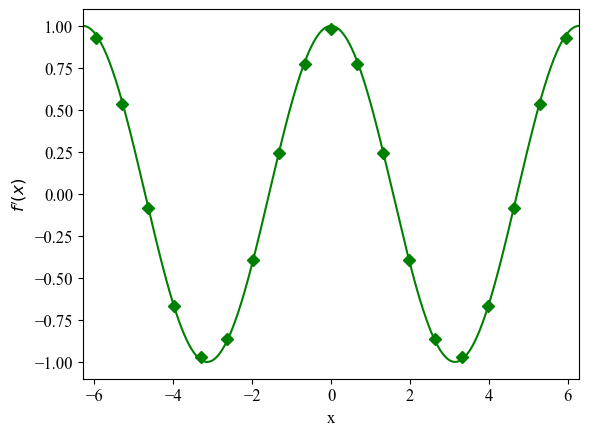

In [8]:
import numpy
import matplotlib.pyplot as plt

f = lambda x: numpy.sin(x)                 # Mendefinisikan fungsi f(x) = sin(x) menggunakan lambda (fungsi anonim)
f_prime = lambda x: numpy.cos(x)           # Turunan analitik dari sin(x) yaitu cos(x), digunakan sebagai pembanding hasil numerik

# Use uniform discretization
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)   # Membuat 1000 titik x dari -2π sampai 2π untuk kurva kontinu
N = 20                                                  # Jumlah titik grid diskrit yang akan dipakai untuk pendekatan numerik
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # Membuat N titik grid yang jaraknya sama (uniform grid)
delta_x = x_hat[1] - x_hat[0]                           # Menghitung jarak antar titik grid (Δx)

print("%s = %s" % (delta_x, (x_hat[-1] - x_hat[0]) / (N - 1)))  
# Mengecek bahwa Δx benar dengan rumus (panjang domain)/(jumlah interval)

# Compute forward difference using a loop
f_prime_hat = numpy.empty(x_hat.shape)     # Membuat array kosong untuk menyimpan hasil turunan numerik                # Membuat array kosong untuk menyimpan hasil turunan numerik

for i in range(N - 1):                                  # Loop untuk menghitung turunan pada setiap titik kecuali titik terakhir
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x  
    # Menghitung turunan menggunakan metode Forward Difference

f_prime_hat[-1] = (f(x_hat[i]) - f(x_hat[i-1])) / delta_x  
# Menghitung turunan di titik terakhir dengan pendekatan backward sederhana

# Vector based calculation
# f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x)
# Alternatif perhitungan tanpa loop menggunakan operasi vektor numpy (lebih cepat)

# Use first-order differences for points at edge of domain
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x  
# Menggunakan Backward Difference pada titik terakhir x_N karena tidak ada titik setelahnya

fig = plt.figure()                       # Membuat objek figure untuk plotting
axes = fig.add_subplot(1, 1, 1)          # Menambahkan satu subplot ke dalam figure

axes.plot(x, f_prime(x), 'g')            # Plot turunan analitik cos(x) dengan garis hijau 
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'gD')  
# Plot hasil turunan numerik dengan titik merah (ro = red circle)

axes.set_xlim((x[0], x[-1]))              # Mengatur batas sumbu x dari nilai minimum sampai maksimum
axes.set_ylim((-1.1, 1.1))                # Mengatur batas sumbu y agar grafik terlihat jelas
axes.set_xlabel("x")                      # Label sumbu x
axes.set_ylabel(r"$f'(x)$")               # Label sumbu y dengan format LaTeX

# Pengaturan tambahan untuk tampilan grafik
plt.rcParams["font.family"] = "Times New Roman"   # Mengubah font grafik menjadi Times New Roman
plt.rcParams["font.size"] = 12                    # Mengatur ukuran font menjadi 12


plt.show()                                

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Contoh: Turunan Orde Kedua

Dengan menggunakan pendekatan deret Taylor, kita akan menurunkan rumus turunan kedua yang memiliki akurasi orde kedua. Sekali lagi kita akan menggunakan titik yang sama dan deret Taylor yang dipusatkan di $x = x_n$ sehingga kita memperoleh ekspresi yang sama seperti sebelumnya:

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \quad A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5)\right ) \\
    &\quad+ B u(x_n) \\
    &\quad+ C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )
\end{aligned}$$

Namun kali ini kita ingin membiarkan $u''(x_n)$ tetap berada di sisi kanan persamaan. Dengan melakukan trik yang sama seperti sebelumnya, kita memperoleh persamaan berikut:

$$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 0 \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 1
\end{aligned}$$

Persamaan kedua menunjukkan bahwa $A = C$, yang jika digabungkan dengan persamaan ketiga menghasilkan

$$A = C = \frac{1}{\Delta x^2}$$

Terakhir, dari persamaan pertama diperoleh

$$B = -\frac{2}{\Delta x^2}$$

yang menghasilkan ekspresi akhir

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \frac{u(x_{n+1}) - 2 u(x_n) + u(x_{n-1})}{\Delta x^2} \\
&\quad+ \frac{1}{\Delta x^2} \left(\frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  \right) + \mathcal{O}(\Delta x^5)
\end{aligned}$$

dengan

$$R(x_n) = \frac{\Delta x^2}{12} u^{(4)}(x_n) + \mathcal{O}(\Delta x^3)$$

</div>

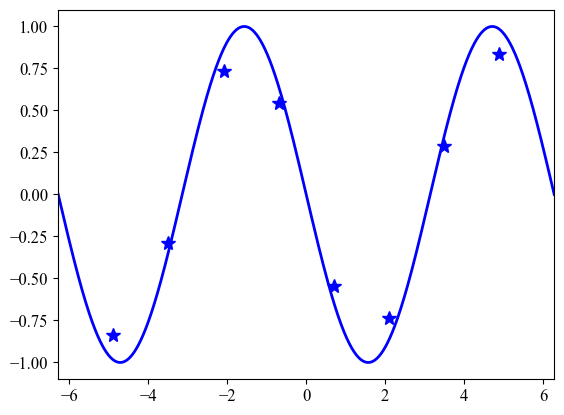

In [9]:
f = lambda x: numpy.sin(x)                     # Mendefinisikan fungsi f(x) = sin(x)
f_dubl_prime = lambda x: -numpy.sin(x)         # Turunan kedua dari sin(x) adalah -sin(x)

# Menggunakan diskretisasi seragam
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)   # Membuat 1000 titik kontinu dari -2π sampai 2π
N = 10                                                  # Jumlah titik grid diskrit
x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # Membuat N titik grid dengan jarak yang sama
delta_x = x_hat[1] - x_hat[0]                           # Menghitung jarak antar titik grid (Δx)

# Menghitung turunan kedua secara numerik
f_dubl_prime_hat = numpy.empty(x_hat.shape)             # Membuat array kosong untuk menyimpan hasil turunan kedua
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) -2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)
# Menggunakan metode Central Difference untuk menghitung turunan kedua pada titik tengah

# Menggunakan selisih orde pertama pada titik tepi domain
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x**2
# Turunan kedua di titik awal (forward difference)

f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x**2
# Turunan kedua di titik akhir (backward difference)

plt.rcParams["font.family"] = "Times New Roman"   # Mengubah font grafik menjadi Times New Roman
plt.rcParams["font.size"] = 12                    # Mengatur ukuran font menjadi 12

fig = plt.figure()                          # Membuat objek figure
axes = fig.add_subplot(1, 1, 1)             # Menambahkan subplot

axes.plot(x, f_dubl_prime(x), color='blue', linewidth=2)          # Grafik turunan kedua analitik
axes.plot(x_hat, f_dubl_prime_hat, marker='*', linestyle='None', color='blue', markersize=10)  
# Grafik hasil turunan numerik dengan marker bintang

axes.set_xlim((x[0], x[-1]))                # Batas sumbu x
axes.set_ylim((-1.1, 1.1))                  # Batas sumbu y

plt.show()                                  # Menampilkan grafik

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Penurunan Umum (General Derivation)

Untuk pendekatan beda hingga (finite difference) secara umum yang terletak pada $\bar{x}$ untuk turunan ke-$k$ dengan stencil sembarang yang terdiri dari $N \geq k + 1$ titik $x_1, \ldots, x_N$, kita dapat menggunakan beberapa generalisasi dari metode sebelumnya. 

Perlu diperhatikan bahwa walaupun biasanya $\bar{x}$ merupakan salah satu titik dalam stencil, hal tersebut **tidak selalu diperlukan**. Kita juga mengasumsikan bahwa fungsi $u(x)$ cukup halus (smooth) sehingga deret Taylor yang digunakan tetap valid.

Pada setiap titik stencil, kita memiliki pendekatan:

$$
u(x_i) = u(\bar{x}) + (x_i - \bar{x})u'(\bar{x}) + \cdots + \frac{1}{k!}(x_i - \bar{x})^k u^{(k)}(\bar{x}) + \cdots.
$$

Mengikuti metodologi sebelumnya, kita ingin mencari **kombinasi linear dari ekspansi deret Taylor tersebut** sehingga diperoleh

$$
u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p) = a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_n u(x_n).
$$

Perlu diperhatikan bahwa secara umum $\Delta x$ dapat bervariasi, dan perilaku asimtotik metode ini biasanya ditentukan oleh suatu **jarak rata-rata** atau kadang oleh **jarak maksimum antar titik stencil**.

Dengan menggeneralisasi pendekatan sebelumnya menggunakan **metode koefisien tak tentu (method of undetermined coefficients)**, kita ingin menghilangkan bagian-bagian pada pendekatan di atas yang berada di depan turunan dengan orde **lebih kecil dari $k$**. 

Syarat untuk hal tersebut adalah

$$
\frac{1}{(i - 1)!} \sum^N_{j=1} a_j (x_j - \bar{x})^{(i-1)} =
\left \{
\begin{aligned}
1 & & \text{jika} \quad i - 1 = k, \\
0 & & \text{selain itu}
\end{aligned}
\right .
$$

untuk $i=1, \ldots, N$.

Dengan asumsi bahwa semua titik $x_j$ **berbeda satu sama lain**, sistem persamaan ini dapat dituliskan dalam bentuk **sistem Vandermonde**, yang memiliki **solusi unik**.

</div>

In [10]:
import scipy.special                           # Mengimpor modul scipy.special yang berisi fungsi matematika seperti factorial

def finite_difference(k, x_bar, x):             # Membuat fungsi untuk menghitung koefisien finite difference turunan ke-k; k = orde turunan, x_bar = titik pusat turunan, x = titik-titik stencil

    """Compute the finite difference stencil for the kth derivative"""  # Dokumentasi fungsi bahwa kode ini menghitung koefisien finite difference

    N = x.shape[0]                              # Menentukan jumlah titik stencil; x.shape[0] digunakan untuk mengambil jumlah elemen array x

    A = numpy.ones((N, N))                      # Membuat matriks A berukuran N×N yang berisi angka 1; numpy.ones digunakan untuk membuat matriks dengan semua elemen bernilai 1

    x_row = x - x_bar                           # Menghitung selisih setiap titik x terhadap titik pusat x_bar; nilai ini digunakan dalam ekspansi deret Taylor

    for i in range(1, N):                       # Perulangan dari 1 sampai N-1 untuk mengisi baris matriks A berdasarkan rumus deret Taylor
        A[i, :] = x_row ** i / scipy.special.factorial(i)   # Mengisi baris matriks dengan rumus (x-x_bar)^i / i!; factorial digunakan untuk menghitung nilai i!

    b = numpy.zeros(N)                          # Membuat vektor b dengan N elemen bernilai 0; numpy.zeros digunakan untuk membuat array berisi nol

    b[k] = 1.0                                  # Mengubah elemen ke-k pada vektor b menjadi 1; ini menunjukkan turunan ke-k yang ingin dihitung

    c = numpy.linalg.solve(A, b)                # Menyelesaikan sistem persamaan linear A*c = b; numpy.linalg.solve digunakan untuk mencari solusi vektor c

    return c                                    # Mengembalikan hasil perhitungan berupa koefisien finite difference yang tersimpan pada variabel c


print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))      # Menghitung koefisien turunan kedua di titik 0 menggunakan stencil [-1,0,1]

print(finite_difference(1, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))      # Menghitung koefisien turunan pertama di titik 0 menggunakan stencil yang sama

print(finite_difference(1, -2.0, numpy.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))   # Menghitung turunan pertama di titik -2 menggunakan lima titik stencil

print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)   # Menghitung turunan kedua dengan enam titik stencil lalu mengalikan hasil dengan 12

[ 1. -2.  1.]
[-0.5  0.   0.5]
[-2.08333333  4.         -3.          1.33333333 -0.25      ]
[ 10. -15.  -4.  14.  -6.   1.]


<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Analisis Error

### Pandangan Polinomial (Polynomial View)

Diberikan $N + 1$ titik, kita dapat membentuk sebuah polinom interpolasi $P_N(x)$ dengan derajat $N$ sehingga

$$
u(x) = P_N(x) + R_N(x)
$$

Dari **Teorema Lagrange**, kita mengetahui bahwa suku sisa (remainder) memiliki bentuk

$$
R_N(x) = (x - x_0)(x - x_1)\cdots (x - x_{N})(x - x_{N+1}) \frac{u^{(N+1)}(c)}{(N+1)!}
$$

dengan catatan bahwa kita harus mengasumsikan bahwa fungsi $u(x) \in C^{N+1}$ pada interval yang sedang dipelajari (artinya fungsi tersebut memiliki turunan hingga orde $N+1$ yang kontinu).

Jika kita mengambil turunan dari polinom interpolasi $P_N(x)$ (dalam bentuk **polinom Newton**) maka diperoleh

$$
\begin{aligned}
P_N'(x) &= [u(x_0), u(x_1)] + ((x - x_1) + (x - x_0)) [u(x_0), u(x_1), u(x_2)] + \cdots \\
&\quad + \left(\sum^{N-1}_{i=0}\left( \prod^{N-1}_{j=0,~j\neq i} (x - x_j) \right )\right ) [u(x_0), u(x_1), \ldots, u(x_N)]
\end{aligned}
$$

Dengan cara yang sama, kita juga dapat mencari turunan dari suku sisa $R_N(x)$

$$
R_N'(x) = \left(\sum^{N}_{i=0} \left( \prod^{N}_{j=0,~j\neq i} (x - x_j) \right )\right ) \frac{u^{(N+1)}(c)}{(N+1)!}
$$

Sekarang jika kita mempertimbangkan pendekatan turunan yang dievaluasi pada salah satu titik data $(x_k, y_k)$, maka persamaan tersebut menjadi lebih sederhana sehingga

$$
u'(x_k) = P_N'(x_k) + R_N'(x_k)
$$

Jika kita mendefinisikan $\Delta x = \max_i |x_k - x_i|$, maka diketahui bahwa suku sisa akan berorde

$$
\mathcal{O}(\Delta x^N)
$$

ketika $\Delta x \rightarrow 0$. Hal ini menunjukkan bahwa metode ini **konvergen**, dan kita dapat memperoleh pendekatan dengan **orde yang sangat tinggi**.


### Error Pemotongan (Truncation Error)

Jika kita menggunakan pendekatan **deret Taylor**, kita juga dapat melihat suku dominan yang tersisa dalam deret Taylor untuk menentukan **truncation error** (kesalahan pemotongan).

Sebagai contoh, kita kembali mempertimbangkan pendekatan turunan pertama. Kita memerlukan ekspansi deret Taylor berikut:

$$
u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

dan

$$
u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

Dengan memasukkan ekspansi ini ke dalam rumus pendekatan turunan, diperoleh

$$
\begin{aligned}
D_+ u(\bar{x}) &= \frac{u(\bar{x} + \Delta x) - u(\bar{x})}{\Delta x} \\
&= \frac{\Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)}{\Delta x} \\
&= u'(\bar{x}) + \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3).
\end{aligned}
$$

Jika kita menghitung selisih antara pendekatan dan turunan sebenarnya, yaitu

$$
D_+ u(\bar{x}) - u'(\bar{x}),
$$

maka diperoleh **truncation error**

$$
\frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3)
$$

Sehingga error untuk metode **forward difference ($D_+$)** berorde

$$
\mathcal{O}(\Delta x)
$$

dan dikendalikan oleh turunan kedua $u''(\bar{x})$. Perhatikan bahwa pendekatan ini bergantung pada $\Delta x$, sedangkan turunan yang dievaluasi di $\bar{x}$ merupakan konstanta.

Untuk pendekatan **centered difference**, diperoleh

$$
D_0 u(\bar{x}) - u'(\bar{x}) = \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$



### Menghitung Orde Akurasi Secara Grafis

Modelkan error sebagai

$$
\begin{aligned}
e(\Delta x) &= C \Delta x^n \\
\log e(\Delta x) &= \log C + n \log \Delta x
\end{aligned}
$$

Kemiringan (slope) dari garis pada grafik **$\log(e)$ terhadap $\log(\Delta x)$** adalah nilai **$n$**, yaitu **orde akurasi metode**.

Kita juga dapat menentukan konstanta $C$ dengan mencocokkan titik pertama:

$$
C = e^{\log e(\Delta x) - n \log \Delta x}
$$

</div>

<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\2470058436.py:60: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\2470058436.py:63: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$", fontname="Times New Roman", fontsize=12)


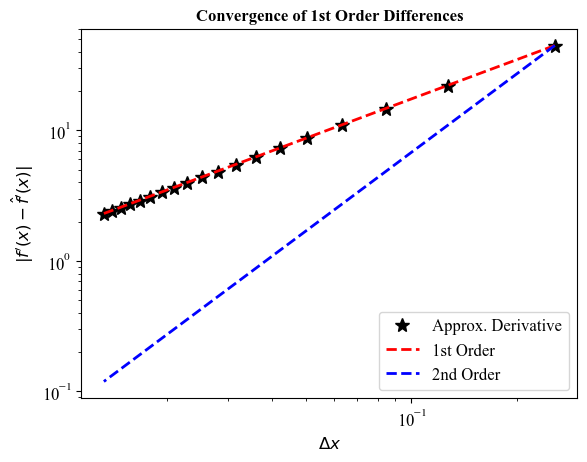

In [11]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3        # Mendefinisikan fungsi f(x) = sin(x) + x^2 + 3x^3 menggunakan lambda (fungsi anonim)
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2  # Mendefinisikan turunan analitik dari fungsi f(x) yang akan dipakai sebagai pembanding hasil numerik

# Menghitung error sebagai fungsi dari delta_x
delta_x = []                                          # Membuat list kosong untuk menyimpan nilai jarak grid (Δx)
error = []                                            # Membuat list kosong untuk menyimpan error hasil turunan numerik

# for N in xrange(2, 101):
for N in range(50, 1000, 50):                         # Melakukan perulangan jumlah titik grid dari 50 sampai 950 dengan kenaikan 50
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # Membuat N titik grid dari -2π sampai 2π menggunakan numpy.linspace
    delta_x.append(x_hat[1] - x_hat[0])                # Menghitung jarak antar titik grid lalu menyimpannya ke list delta_x

    # Menghitung turunan menggunakan metode Forward Difference
    f_prime_hat = numpy.empty(x_hat.shape)             # Membuat array kosong untuk menyimpan hasil turunan numerik
    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x[-1])  
                                                        # Menghitung turunan numerik dengan rumus forward difference
                                                        # x_hat[1:] adalah semua titik kecuali pertama
                                                        # x_hat[:-1] adalah semua titik kecuali terakhir
                                                        # delta_x[-1] berarti mengambil nilai Δx terakhir dari list

    # Menggunakan selisih orde pertama pada titik tepi domain
    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]  
                                                        # Menghitung turunan di titik terakhir menggunakan Backward Difference
                                                        # diperlukan karena tidak ada titik setelah x_N

    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat), ord=numpy.inf))
                                                        # Menghitung error maksimum antara turunan analitik dan turunan numerik
                                                        # numpy.abs digunakan untuk mengambil nilai absolut
                                                        # numpy.linalg.norm digunakan untuk menghitung norma error
                                                        # ord = numpy.inf berarti menggunakan norma tak hingga (maksimum error)

error = numpy.array(error)                             # Mengubah list error menjadi array numpy agar mudah diproses
delta_x = numpy.array(delta_x)                         # Mengubah list delta_x menjadi array numpy

fig = plt.figure()                                     # Membuat objek figure untuk grafik
axes = fig.add_subplot(1, 1, 1)                        # Menambahkan satu subplot ke dalam figure

axes.loglog(delta_x, error, marker='*', linestyle='None', color='black', markersize=10, label="Approx. Derivative")  
                                                        # Membuat grafik log-log antara delta_x dan error
                                                        # marker='*' mengubah titik menjadi bintang
                                                        # linestyle='None' menghilangkan garis penghubung antar titik

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
                                                        # Fungsi untuk menghitung konstanta C pada model error e(Δx)=CΔx^n
                                                        # numpy.log digunakan untuk logaritma
                                                        # numpy.exp digunakan untuk fungsi eksponensial

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'r--', linewidth=2, label="1st Order")
                                                        # Menggambar garis referensi orde pertama (Δx^1) dengan garis putus merah

axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'b--', linewidth=2, label="2nd Order")
                                                        # Menggambar garis referensi orde kedua (Δx^2) dengan garis putus biru

axes.legend(loc=4, prop={'family':'Times New Roman','size':12})
                                                        # Menampilkan legenda grafik di posisi kanan bawah dengan font Times New Roman ukuran 12

axes.set_title("Convergence of 1st Order Differences", fontname="Times New Roman", fontsize=12, fontweight='bold')
                                                        # Memberi judul grafik dengan font Times New Roman ukuran 12 dan teks tebal

axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
                                                        # Memberi label sumbu x dengan font Times New Roman ukuran 12

axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$", fontname="Times New Roman", fontsize=12)
                                                        # Memberi label sumbu y dengan font Times New Roman ukuran 12

plt.show()                                             # Menampilkan grafik hasil perhitungan

<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\461348125.py:60: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\461348125.py:63: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$", fontname="Times New Roman", fontsize=12)


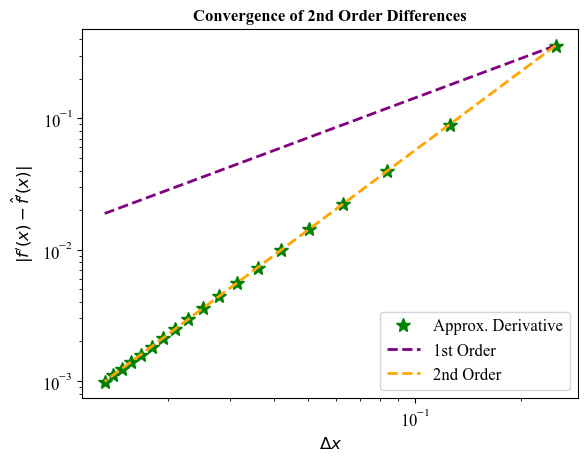

In [12]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3        # Mendefinisikan fungsi f(x) = sin(x) + x^2 + 3x^3 menggunakan lambda
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2  # Mendefinisikan turunan analitik dari fungsi f(x) sebagai pembanding

# Menghitung error sebagai fungsi dari delta_x
delta_x = []                                          # List kosong untuk menyimpan jarak antar titik grid (Δx)
error = []                                            # List kosong untuk menyimpan error hasil turunan numerik

# for N in xrange(2, 101):
for N in range(50, 1000, 50):                         # Perulangan jumlah titik grid dari 50 sampai 950 dengan kenaikan 50
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N + 1)  # Membuat N+1 titik grid dari -2π sampai 2π
    delta_x.append(x_hat[1] - x_hat[0])                # Menghitung jarak antar titik grid lalu menyimpannya

    # Menghitung turunan numerik menggunakan Central Difference
    f_prime_hat = numpy.empty(x_hat.shape)             # Membuat array kosong untuk menyimpan hasil turunan numerik
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])
                                                        # Menghitung turunan numerik pada titik tengah menggunakan rumus central difference

    # Menggunakan selisih orde kedua pada titik tepi domain
#     f_prime_hat[0] = (f(x_hat[1]) - f(x_hat[0])) / delta_x[-1]  
#     f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]

    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])
                                                        # Menghitung turunan di titik awal menggunakan forward difference orde kedua

    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])
                                                        # Menghitung turunan di titik akhir menggunakan backward difference orde kedua
    
    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat) - f_prime_hat), ord=numpy.inf))
                                                        # Menghitung error maksimum antara turunan analitik dan numerik
                                                        # numpy.abs untuk nilai absolut
                                                        # numpy.linalg.norm untuk menghitung norma
                                                        # ord = numpy.inf berarti mengambil error maksimum
    
error = numpy.array(error)                             # Mengubah list error menjadi array numpy
delta_x = numpy.array(delta_x)                         # Mengubah list delta_x menjadi array numpy
    
fig = plt.figure()                                     # Membuat objek figure
axes = fig.add_subplot(1, 1, 1)                        # Menambahkan satu subplot

axes.loglog(delta_x, error, marker='*', linestyle='None', color='green', markersize=10, label="Approx. Derivative")
                                                        # Membuat grafik log-log antara delta_x dan error
                                                        # marker='*' membuat titik berbentuk bintang
                                                        # warna hijau untuk membedakan dari grafik sebelumnya

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
                                                        # Fungsi untuk menghitung konstanta C pada model error e(Δx)=CΔx^n

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, '--', color='purple', linewidth=2, label="1st Order")
                                                        # Garis referensi orde pertama (Δx^1) berwarna ungu

axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, '--', color='orange', linewidth=2, label="2nd Order")
                                                        # Garis referensi orde kedua (Δx^2) berwarna oranye

axes.legend(loc=4, prop={'family':'Times New Roman','size':12})
                                                        # Menampilkan legenda grafik dengan font Times New Roman ukuran 12

axes.set_title("Convergence of 2nd Order Differences", fontname="Times New Roman", fontsize=12, fontweight='bold')
                                                        # Judul grafik dengan font Times New Roman ukuran 12 dan teks tebal

axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
                                                        # Label sumbu x dengan font Times New Roman ukuran 12

axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$", fontname="Times New Roman", fontsize=12)
                                                        # Label sumbu y dengan font Times New Roman ukuran 12

plt.show()                                             # Menampilkan grafik

<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\h'
<>:56: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\567519507.py:56: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
C:\Users\Acer\AppData\Local\Temp\ipykernel_4528\567519507.py:59: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f''(x) - \hat{f}''(x)|$", fontname="Times New Roman", fontsize=12)


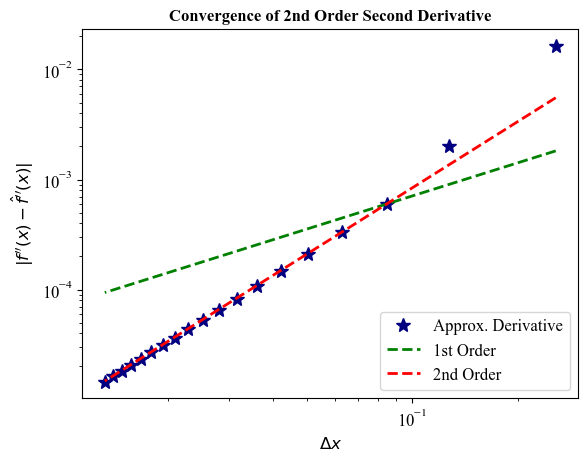

In [13]:
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3            # Mendefinisikan fungsi f(x) = sin(x) + x^2 + 3x^3 menggunakan lambda
f_dubl_prime = lambda x: -numpy.sin(x) + 2.0 + 18.0 * x   # Mendefinisikan turunan kedua analitik dari fungsi f(x) sebagai pembanding

# Menghitung error sebagai fungsi dari delta_x
delta_x = []                                              # List kosong untuk menyimpan jarak grid (Δx)
error = []                                                # List kosong untuk menyimpan error hasil turunan numerik

# for N in xrange(2, 101):
for N in range(50, 1000, 50):                             # Perulangan jumlah titik grid dari 50 sampai 950 dengan kenaikan 50
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # Membuat N titik grid dari -2π sampai 2π
    delta_x.append(x_hat[1] - x_hat[0])                    # Menghitung jarak antar titik grid lalu menyimpannya ke list

    # Menghitung turunan kedua numerik
    f_dubl_prime_hat = numpy.empty(x_hat.shape)            # Membuat array kosong untuk menyimpan hasil turunan numerik
    f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) -2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x[-1]**2)
                                                           # Menghitung turunan kedua menggunakan rumus central difference

    # Menggunakan selisih orde kedua pada titik tepi domain
    f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x[-1]**2
                                                           # Menghitung turunan kedua di titik awal menggunakan forward difference orde kedua

    f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x[-1]**2
                                                           # Menghitung turunan kedua di titik akhir menggunakan backward difference orde kedua
    
    error.append(numpy.linalg.norm(numpy.abs(f_dubl_prime(x_hat) - f_dubl_prime_hat), ord=numpy.inf))
                                                           # Menghitung error maksimum antara turunan analitik dan numerik
                                                           # numpy.abs mengambil nilai absolut
                                                           # numpy.linalg.norm menghitung norma
                                                           # ord=numpy.inf berarti mengambil error maksimum
    
error = numpy.array(error)                                 # Mengubah list error menjadi array numpy
delta_x = numpy.array(delta_x)                             # Mengubah list delta_x menjadi array numpy
    
fig = plt.figure()                                         # Membuat objek figure
axes = fig.add_subplot(1, 1, 1)                            # Menambahkan satu subplot

axes.loglog(delta_x, error, marker='*', linestyle='None', color='navy', markersize=10, label="Approx. Derivative")
                                                           # Membuat grafik log-log antara delta_x dan error
                                                           # marker='*' membuat titik berbentuk bintang
                                                           # warna biru tua agar berbeda dari grafik sebelumnya

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
                                                           # Fungsi untuk menghitung konstanta C pada model error e(Δx)=CΔx^n

axes.loglog(delta_x, order_C(delta_x[2], error[2], 1.0) * delta_x**1.0, '--', color='green', linewidth=2, label="1st Order")
                                                           # Garis referensi orde pertama dengan warna hijau putus-putus

axes.loglog(delta_x, order_C(delta_x[2], error[2], 2.0) * delta_x**2.0, '--', color='red', linewidth=2, label="2nd Order")
                                                           # Garis referensi orde kedua dengan warna merah putus-putus

axes.legend(loc=4, prop={'family':'Times New Roman','size':12})  # Menampilkan legenda dengan font Times New Roman ukuran 12

axes.set_title("Convergence of 2nd Order Second Derivative", fontname="Times New Roman", fontsize=12, fontweight='bold')
                                                           # Judul grafik dengan font Times New Roman ukuran 12 dan teks tebal

axes.set_xlabel("$\Delta x$", fontname="Times New Roman", fontsize=12)
                                                           # Label sumbu x dengan font Times New Roman ukuran 12

axes.set_ylabel("$|f''(x) - \hat{f}''(x)|$", fontname="Times New Roman", fontsize=12)
                                                           # Label sumbu y dengan font Times New Roman ukuran 12

plt.show()                                                # Menampilkan grafik